<a href="https://colab.research.google.com/github/pparbhat223-ai/Section2_R_Analytics/blob/main/NorthStar_Section2_R_Analytics_Performance_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 0 – Enable R in Colab

In [ ]:
%load_ext rpy2.ipython

# Step 1 – Install Required Libraries

In [ ]:
%%R

install.packages("tidyverse")
install.packages("lubridate")
install.packages("corrplot")
install.packages("GGally")
install.packages("scales")

library(tidyverse)
library(lubridate)
library(corrplot)
library(GGally)
library(scales)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/tidyverse_2.0.0.tar.gz'
Content type 'application/x-gzip' length 704618 bytes (688 KB)
downloaded 688 KB


The downloaded source packages are in
	‘/tmp/RtmpLcDr8w/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/lubridate_1.9.5.tar.gz'
Content type 'application/x-gzip' length 429855 bytes (419 KB)
downloaded 419 KB


The downloaded source packages are in
	‘/tmp/RtmpLcDr8w/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/corrplot_0.95.tar.gz'
Content type 'application/x-gzip' length 3745190 bytes (3.6 MB)
downloaded 3.6 MB


The downloaded source packages are in
	‘/tmp/RtmpLcDr8w/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’


# Step 2 – Load  Data

In [ ]:
%%R

# Define repository path
repo_path <- "https://raw.githubusercontent.com/pparbhat223-ai/Dataset/refs/heads/main/"

# Load selected datasets
customers <- read.csv(paste0(repo_path, "customers.csv"))
orders    <- read.csv(paste0(repo_path, "orders.csv"))

# Display sample records
head(orders)

In [ ]:
%%R

customers <- read.csv("customers.csv")

orders <- read.csv("orders.csv")

drivers <- read.csv("drivers.csv")

vehicles <- read.csv("vehicles.csv")

complaints <- read.csv("complaints.csv")

app_events <- read.csv("app_events.csv")

incidents <- read.csv("incidents.csv")

hubs <- read.csv("hubs.csv")

# Step 3 – Create Integrated Analytical Dataset

Combining structured operational data to simulate unified view required by management.

In [ ]:
%%R

orders_customers <- orders %>%

left_join(customers, by="customer_id")

orders_complaints <- orders_customers %>%

left_join(complaints, by="order_id")

orders_complaints$has_complaint <- ifelse(is.na(orders_complaints$complaint_id),0,1)

head(orders_complaints)

  order_id customer_id.x service_type    order_created_at promised_window_hours
1   O00001         C0292    Passenger 2024-08-20 14:43:00                     6
2   O00002         C0459    Passenger 2024-05-14 22:16:00                    24
3   O00003         C0161    Passenger 2025-09-02 14:37:00                     4
4   O00004         C0520       Parcel 2025-01-11 17:15:00                     2
5   O00005         C0558       Retail 2025-02-17 19:32:00                    12
6   O00006         C0437       Retail 2024-08-05 04:55:00                     1
  pickup_zone dropoff_zone priority_level order_value booking_channel
1     Airport        South         Medium      126.65             App
2       North      AIRPORT            Low      109.30             App
3        West      AIRPORT           High       33.50           Phone
4   RiverSide        North         Medium       10.04             App
5   Riverside        SOUTH            Low      125.58           Phone
6     CENTRAL       

Business relevance:
Combines service transactions with customer satisfaction indicators.

# Step 4 – Customer dissatisfaction risk analysis

Identify factors influencing complaints.

In [ ]:
%%R

complaint_risk_model <- glm(
has_complaint ~ order_value + loyalty_score + app_engagement_score,
data=orders_complaints,
family=binomial
)

summary(complaint_risk_model)


Call:
glm(formula = has_complaint ~ order_value + loyalty_score + app_engagement_score, 
    family = binomial, data = orders_complaints)

Coefficients:
                       Estimate Std. Error z value Pr(>|z|)   
(Intercept)          -1.0325644  0.3385949  -3.050  0.00229 **
order_value           0.0004931  0.0010518   0.469  0.63920   
loyalty_score         0.0027096  0.0041601   0.651  0.51483   
app_engagement_score -0.0050594  0.0034836  -1.452  0.14641   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1389.7  on 1242  degrees of freedom
Residual deviance: 1386.9  on 1239  degrees of freedom
  (42 observations deleted due to missingness)
AIC: 1394.9

Number of Fisher Scoring iterations: 4



In [ ]:
Insight:
Shows whether high-value customers are more sensitive to service failures.

# Step 5 – Correlation matrix (operational performance indicators)

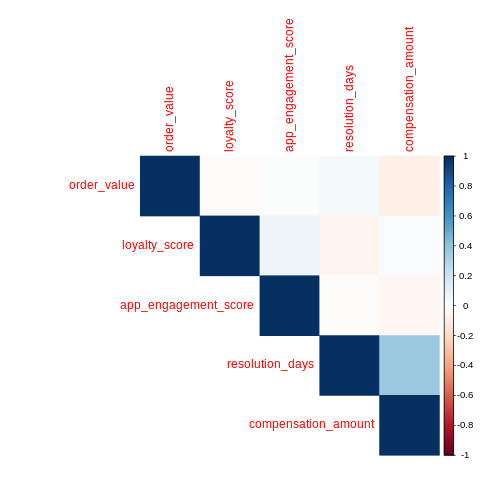

In [ ]:
%%R

performance_data <- orders_complaints %>%

select(order_value,
loyalty_score,
app_engagement_score,
resolution_days,
compensation_amount)

performance_data <- na.omit(performance_data)

cor_matrix <- cor(performance_data)

corrplot(cor_matrix, method="color", type="upper")

Insight:
Identifies relationships between service quality and compensation costs.

# Step 6 – Demand variability analysis by zone and service type

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by pickup_zone and service_type.
ℹ Output is grouped by pickup_zone.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(pickup_zone, service_type))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


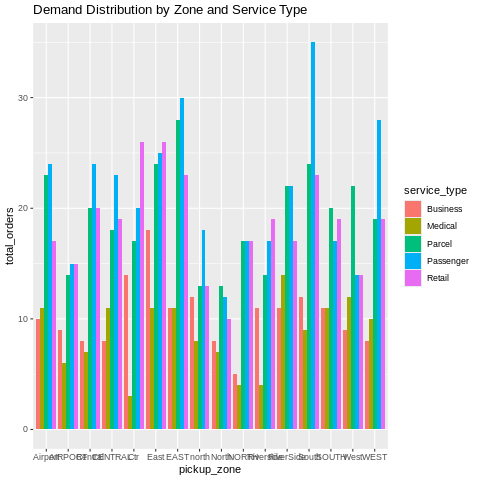

In [ ]:
%%R

demand_pattern <- orders %>%

group_by(pickup_zone, service_type) %>%

summarise(total_orders=n(),
avg_value=mean(order_value))

ggplot(demand_pattern,
aes(x=pickup_zone,
y=total_orders,
fill=service_type))+

geom_bar(stat="identity", position="dodge")+

ggtitle("Demand Distribution by Zone and Service Type")

Insight:
Identifies high pressure zones requiring better dispatch planning.

# Step 7 – Driver performance clustering indicators


(`geom_point()`). 



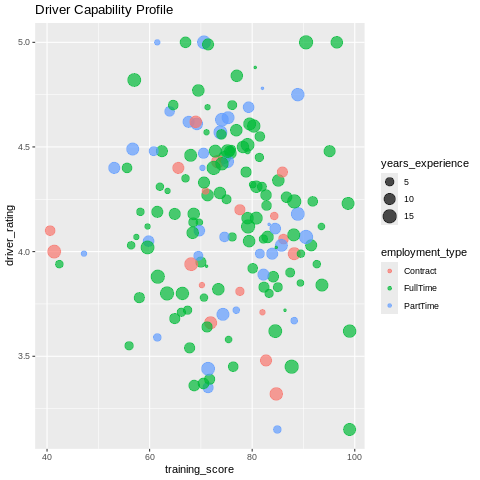

In [ ]:
%%R

ggplot(drivers,
aes(x=training_score,
y=driver_rating,
size=years_experience,
color=employment_type))+

geom_point(alpha=0.7)+

ggtitle("Driver Capability Profile")

Insight:
Identifies high pressure zones requiring better dispatch planning.

# Step 8 – Vehicle operational risk scoring


(`geom_point()`). 



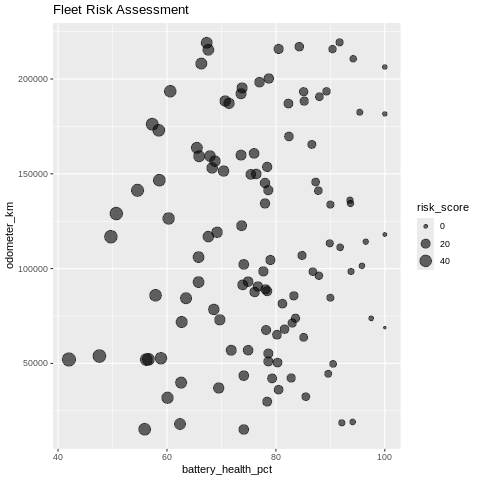

In [ ]:
%%R

vehicles$risk_score <-

(100-vehicles$battery_health_pct) +

scale(vehicles$odometer_km)

ggplot(vehicles,
aes(x=battery_health_pct,
y=odometer_km,
size=risk_score))+

geom_point(alpha=0.6)+

ggtitle("Fleet Risk Assessment")

Insight:
High mileage + low battery health indicates service disruption risk.

# Step 9 – Incident impact severity analysis

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by incident_type and severity.
ℹ Output is grouped by incident_type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(incident_type, severity))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.



(`geom_bar()`). 



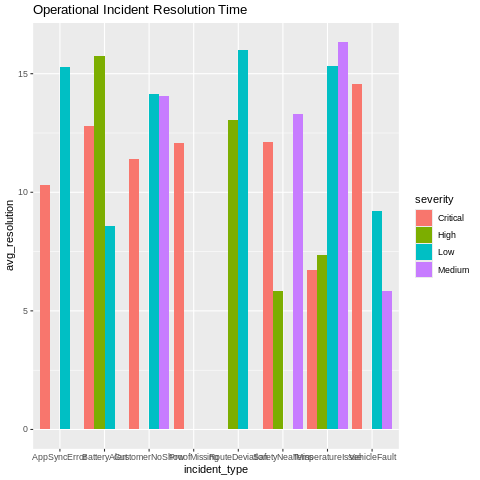

In [ ]:
%%R

incident_analysis <- incidents %>%

group_by(incident_type, severity) %>%

summarise(avg_resolution=mean(resolved_hours))

ggplot(incident_analysis,
aes(x=incident_type,
y=avg_resolution,
fill=severity))+

geom_bar(stat="identity", position="dodge")+

ggtitle("Operational Incident Resolution Time")

Insight:
Identifies incident types causing operational delays.


# Step 10 – App performance impact on customer experience

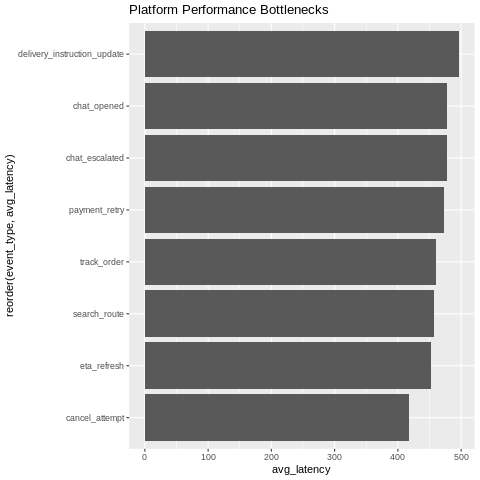

In [ ]:
%%R

app_performance <- app_events %>%

group_by(event_type) %>%

summarise(avg_latency=mean(api_latency_ms))

ggplot(app_performance,
aes(x=reorder(event_type,avg_latency),
y=avg_latency))+

geom_bar(stat="identity")+

coord_flip()+

ggtitle("Platform Performance Bottlenecks")

# Step 11 – Hub pressure index

Compare infrastructure capacity vs demand.

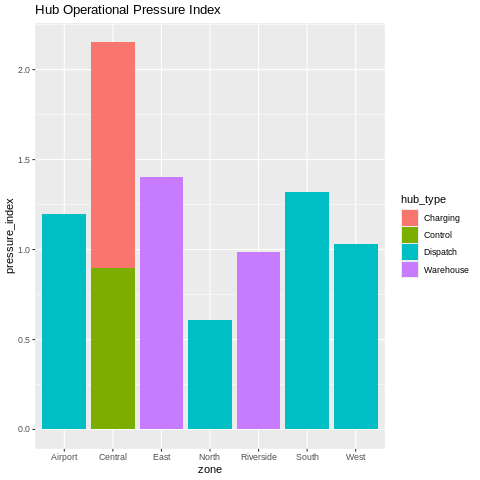

In [ ]:
%%R

zone_demand <- orders %>%

group_by(pickup_zone) %>%

summarise(total_orders=n())

hub_pressure <- hubs %>%

left_join(zone_demand, by=c("zone"="pickup_zone"))

hub_pressure$pressure_index <-

hub_pressure$total_orders /

hub_pressure$capacity_score

ggplot(hub_pressure,
aes(x=zone,
y=pressure_index,
fill=hub_type))+

geom_bar(stat="identity")+

ggtitle("Hub Operational Pressure Index")

Insight:
High pressure hubs may experience delivery bottlenecks.

# Step 12 – Customer segmentation analysis


(`geom_point()`). 



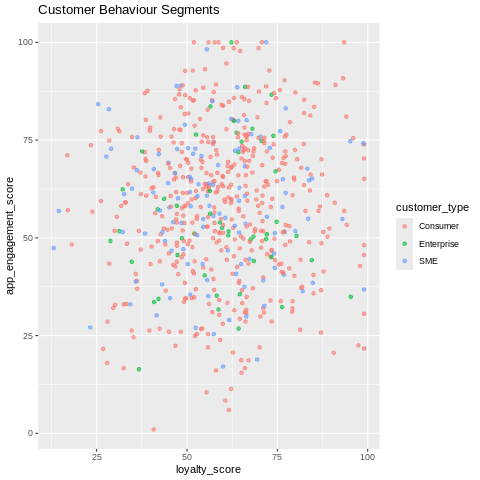

In [ ]:
%%R

ggplot(customers,
aes(x=loyalty_score,
y=app_engagement_score,
color=customer_type))+

geom_point(alpha=0.6)+

ggtitle("Customer Behaviour Segments")

Insight:
Identifies high-value digital customers.